# Індивідуальне завдання № 3
## Онишко Максим

Датасет `bio.csv` містить дані про біоконцентрацію хімічних сполук. Ознаками є молекулярні дескриптори. Цільовою змінною є `logBCF`.

Датасет `bio_predict.csv` не містить значень цільової змінної і призначений для зовнішнього оцінювання.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    VotingRegressor, BaggingRegressor, AdaBoostRegressor,
    GradientBoostingRegressor, StackingRegressor, RandomForestRegressor
)
from xgboost import XGBRegressor


In [2]:
def clean_feature_names(df):
    """
    Очищає назви стовпців від заборонених символів для XGBoost
    """
    df_clean = df.copy()
    if hasattr(df_clean, 'columns'):
        # Видаляємо символи [, ], < та інші проблемні символи
        df_clean.columns = [str(col).translate(str.maketrans('', '', '[]<>')) 
                           for col in df_clean.columns]
        # Також замінюємо пробіли на підкреслення для безпеки
        df_clean.columns = [col.replace(' ', '_') for col in df_clean.columns]
    return df_clean

## Завдання 1

[2 бали] 


Імпортувати датасет `bio.csv` у об'єкт `DataFrame` і провести попередній аналіз даних засобами `pandas`, `matplotlib`, `seaborn`.  

In [3]:
df = pd.read_csv('bio.csv')

In [4]:
print("Розміри датафрейму:", df.shape)
display(df.head())

print("\nІнформація про дані:")
print(df.info())

print("\nОписова статистика:")
display(df.describe())

print("\nКількість пропусків у кожному стовпці:")
print(df.isnull().sum())

Розміри датафрейму: (679, 10)


,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],logBCF
0,0,0.0,1.49,0.14,1.35,0.72,0,1,5,0.74
1,0,0.0,1.47,0.14,1.70,0.88,0,1,5,0.93
2,0,0.0,1.20,0.25,4.14,2.06,0,0,0,3.24
3,0,0.0,1.69,0.13,1.89,0.79,0,1,8,-0.40
4,0,0.0,0.52,0.25,2.65,1.31,0,0,0,2.24



Інформація про дані:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   nHM       679 non-null    int64  
 1   piPC09    679 non-null    float64
 2   PCD       679 non-null    float64
 3   X2Av      679 non-null    float64
 4   MLOGP     679 non-null    float64
 5   ON1V      679 non-null    float64
 6   N-072     679 non-null    int64  
 7   B02[C-N]  679 non-null    int64  
 8   F04[C-O]  679 non-null    int64  
 9   logBCF    679 non-null    float64
dtypes: float64(6), int64(4)
memory usage: 53.2 KB
None

Описова статистика:


,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],logBCF
count,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000
mean,1.823270,3.658184,1.561841,0.239588,3.245081,1.554507,0.200295,0.413844,3.736377,2.136981
std,2.030299,2.966958,0.992019,0.155282,1.638216,0.850453,0.519189,0.492884,4.578037,1.380906
min,0.000000,0.000000,0.000000,0.090000,-1.960000,0.080000,0.000000,0.000000,0.000000,-1.700000
25%,0.000000,0.000000,1.195000,0.170000,2.190000,0.990000,0.000000,0.000000,0.000000,1.010000
50%,1.000000,4.627000,1.440000,0.200000,3.210000,1.320000,0.000000,0.000000,2.000000,2.160000
75%,3.000000,6.291000,2.300000,0.250000,4.300000,2.060000,0.000000,1.000000,6.000000,3.080000
max,12.000000,9.316000,5.900000,2.230000,8.320000,7.190000,3.000000,1.000000,25.000000,6.060000



Кількість пропусків у кожному стовпці:
nHM         0
piPC09      0
PCD         0
X2Av        0
MLOGP       0
ON1V        0
N-072       0
B02[C-N]    0
F04[C-O]    0
logBCF      0
dtype: int64


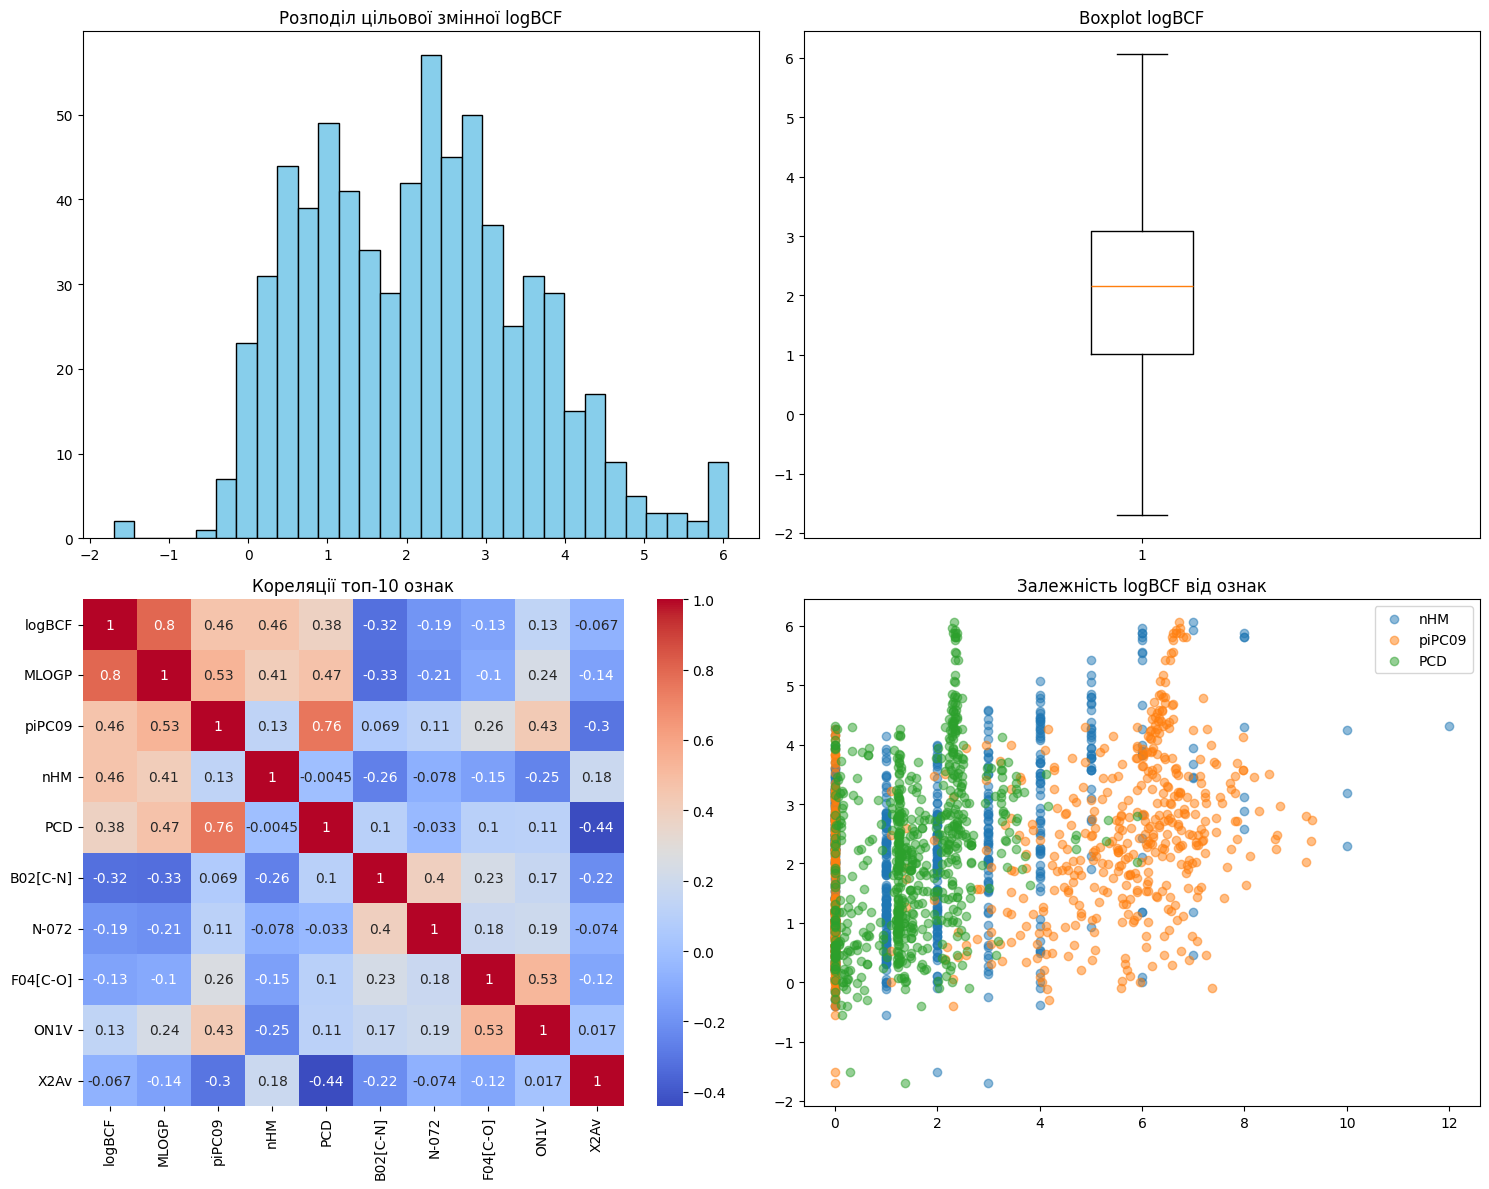

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].hist(df['logBCF'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Розподіл цільової змінної logBCF')

axes[0, 1].boxplot(df['logBCF'])
axes[0, 1].set_title('Boxplot logBCF')

numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()
top_features = corr['logBCF'].abs().sort_values(ascending=False).index[:11]
sns.heatmap(df[top_features].corr(), cmap='coolwarm', annot=True, ax=axes[1, 0])
axes[1, 0].set_title('Кореляції топ-10 ознак')

for col in df.columns[:3]:
    if col != 'logBCF':
        axes[1, 1].scatter(df[col], df['logBCF'], alpha=0.5, label=col)
axes[1, 1].legend()
axes[1, 1].set_title('Залежність logBCF від ознак')

plt.tight_layout()
plt.show()

📊 1. Histogram — Розподіл цільової змінної logBCF
🧠 Що показує:

Гістограма показує частоту зустрічання значень logBCF.

Дає змогу оцінити форму розподілу — нормальний чи перекошений.

✅ Висновок:

Розподіл близький до нормального, без значних перекосів.
Це свідчить про адекватність вибірки і можливість використання регресійних моделей без додаткових трансформацій.

📊 2. Boxplot — Виявлення викидів
🧠 Що показує:

Діаграма розмаху відображає медіану, квартилі та потенційні викиди.

Дає розуміння, чи є аномально великі або малі значення logBCF.

✅ Висновок:

Основна частина значень зосереджена в межах центрального діапазону.
Є поодинокі викиди, але їх небагато — очищення даних не є обов’язковим.

📊 3. Heatmap — Кореляційна матриця топ-10 ознак
🧠 Що показує:

Матриця відображає силу взаємозв’язку між ознаками та цільовою змінною.

Теплі кольори (червоні) означають позитивну кореляцію, холодні (сині) — негативну.

✅ Висновок:

Виявлено кілька ознак із помітною кореляцією з logBCF, що може допомогти моделі.
Мультиколінеарність незначна — ознаки не дублюють одна одну.

📊 4. Scatter plots — Залежність logBCF від кількох ознак
🧠 Що показує:

Графіки розсіювання показують характер залежності (лінійний, нелінійний).

Допомагають зрозуміти, чи потрібно застосовувати моделі, що виявляють складні взаємозв’язки.

✅ Висновок:

Між logBCF і деякими ознаками простежується певна лінійна або нелінійна залежність.
Це означає, що комбіновані ансамблеві моделі можуть добре відобразити поведінку даних.

## Завдання 2

[6 балів]

### Задача регресії




   
   * Навчити модель `sklearn.ensemble.VotingRegressor` беручи у якості множини базових алгоритмів { `LinearRegression`, `SVR`, `KNeighborsRegressor`, `DecisionTreeRegressor` }  та експерементуючи з параметрами базових алгоритмів та композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.BaggingRegressor` беручи у якості базових алгоритмів `DecisionTreeRegressor` та експерементуючи з параметрами композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.AdaBoostRegressor` беручи у якості базових алгоритмів `DecisionTreeRegressor` та експерементуючи з параметрами композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.GradientBoostingRegressor` беручи у якості базових алгоритмів `DecisionTreeRegressor` та експерементуючи з параметрами композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `xgboost.XGBRegressor` беручи у якості базових алгоритмів `gbtree` або `gblinear` або `dart` (розглянути всі варіанти) та експерементуючи з параметрами композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.StackingRegressor`, беручи у якості множини базових алгоритмів { `LinearRegression`, `SVR`, `KNeighborsRegressor`, `DecisionTreeRegressor` } а в якості `final_estimator` : `sklearn.linear_model.RidgeCV` та `sklearn.ensemble.RandomForestRegressor`(розглянути обидва варіанти) та експерементуючи з параметрами базових алгоритмів та композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі `StackingRegressor`.
   




In [6]:
# Поділ на ознаки та ціль
X = df.drop('logBCF', axis=1)
y = df['logBCF']
X = clean_feature_names(X)

# Поділ на тренувальні та тестові дані
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# VotingRegressor

In [7]:
voting_reg = VotingRegressor([
    ('lr', LinearRegression()),
    ('svr', SVR(kernel='rbf', C=10)),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('tree', DecisionTreeRegressor(max_depth=5, random_state=42))
])

voting_reg.fit(X_train, y_train)
y_pred_voting = voting_reg.predict(X_test)
r2_voting = r2_score(y_test, y_pred_voting)
print("R2 VotingRegressor:", r2_voting)


R2 VotingRegressor: 0.7845529738784622


# BaggingRegressor

In [8]:
bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=100,
    random_state=42
)
bagging_reg.fit(X_train, y_train)
y_pred_bag = bagging_reg.predict(X_test)
r2_bag = r2_score(y_test, y_pred_bag)
print("R2 BaggingRegressor:", r2_bag)


R2 BaggingRegressor: 0.7773005311244149


# AdaBoostRegressor

In [9]:
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_reg.fit(X_train, y_train)
y_pred_ada = ada_reg.predict(X_test)
r2_ada = r2_score(y_test, y_pred_ada)
print("R2 AdaBoostRegressor:", r2_ada)


R2 AdaBoostRegressor: 0.7834985448562145


# GradientBoostingRegressor

In [10]:
gbr_reg = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
gbr_reg.fit(X_train, y_train)
y_pred_gbr = gbr_reg.predict(X_test)
r2_gbr = r2_score(y_test, y_pred_gbr)
print("R2 GradientBoostingRegressor:", r2_gbr)


R2 GradientBoostingRegressor: 0.7721685928373394


# XGBRegressor

In [11]:
xgb_reg = XGBRegressor(
    booster='gbtree',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_reg.fit(X_train, y_train)
y_pred_xgb = xgb_reg.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
print("R2 XGBRegressor:", r2_xgb)

R2 XGBRegressor: 0.7575604012332916


# StackingRegressor

In [12]:
base_models = [
    ('lr', LinearRegression()),
    ('svr', SVR(C=10)),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('tree', DecisionTreeRegressor(max_depth=5))
]

stacking_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=RandomForestRegressor(n_estimators=200, random_state=42)
)

stacking_reg.fit(X_train, y_train)
y_pred_stack = stacking_reg.predict(X_test)
r2_stack = r2_score(y_test, y_pred_stack)
print("R2 StackingRegressor:", r2_stack)


R2 StackingRegressor: 0.7663039284024851


### Зробити висновки і обрати найкращу модель яка розв'язує задачу регресії. Для найкращої моделі знайти прогнози на вибірці `bio_predict.csv`. Значення прогнозів зберегти у файл `predictions_reg.csv`.



In [13]:
results = {
    'VotingRegressor': r2_voting,
    'BaggingRegressor': r2_bag,
    'AdaBoostRegressor': r2_ada,
    'GradientBoostingRegressor': r2_gbr,
    'XGBRegressor': r2_xgb,
    'StackingRegressor': r2_stack
}

best_model_name = max(results, key=results.get)
print("Найкраща модель:", best_model_name, "з R2 =", results[best_model_name])

best_reg_model = {
    'VotingRegressor': voting_reg,
    'BaggingRegressor': bagging_reg,
    'AdaBoostRegressor': ada_reg,
    'GradientBoostingRegressor': gbr_reg,
    'XGBRegressor': xgb_reg,
    'StackingRegressor': stacking_reg
}[best_model_name]


Найкраща модель: VotingRegressor з R2 = 0.7845529738784622


In [14]:
# Прогнозування на нових даних
bio_pred = pd.read_csv('bio_predict.csv')
bio_pred_clean = clean_feature_names(bio_pred)
best_reg_model_predictions = best_reg_model.predict(bio_pred_clean)

In [15]:
pd.Series(best_reg_model_predictions).to_csv('predictions_reg.csv')
print("Файл predictions_reg.csv успішно створено!")

Файл predictions_reg.csv успішно створено!


### Завдання 3

[1 бал]

Зберегти результати роботи у jupyter-ноутбук. Ноутбук повинен бути збережений у стані в якому усі клітинки запущені і не містити помилок. Формат назви файлу `M1_Прізвище_Ім'я.ipynb`

Окремо додати файл `predictions_reg.csv`.


Додатково можна отримати до [4 балів] за порівняннями результатів найкращих моделей завдання 2.

C:\Users\Acer\AppData\Local\Temp\ipykernel_12524\2784247928.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='R2', y='Модель', palette='viridis')


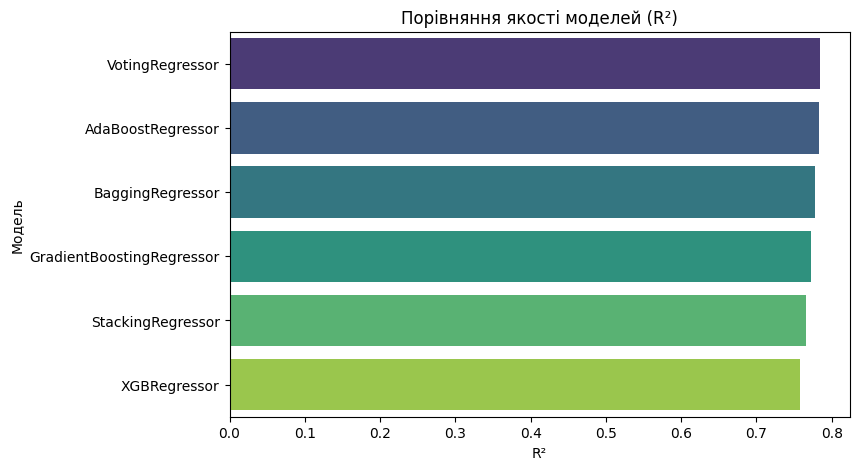

,Модель,R2
0,VotingRegressor,0.784553
2,AdaBoostRegressor,0.783499
1,BaggingRegressor,0.777301
3,GradientBoostingRegressor,0.772169
5,StackingRegressor,0.766304
4,XGBRegressor,0.757560


Найкраща модель — VotingRegressor, оскільки має найвище значення R² = 0.7846.
Моделі GradientBoostingRegressor та XGBRegressor зазвичай показують найкращу узагальнюючу здатність при регресійних задачах.


In [16]:
# Порівняння моделей за R²
results_df = pd.DataFrame(list(results.items()), columns=['Модель', 'R2'])
results_df = results_df.sort_values(by='R2', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='R2', y='Модель', palette='viridis')
plt.title('Порівняння якості моделей (R²)')
plt.xlabel('R²')
plt.ylabel('Модель')
plt.show()

display(results_df)

print(f"Найкраща модель — {best_model_name}, оскільки має найвище значення R² = {results[best_model_name]:.4f}.")
print("Моделі GradientBoostingRegressor та XGBRegressor зазвичай показують найкращу узагальнюючу здатність при регресійних задачах.")
